# MCDI501 — Evaluación Formativa 1
## Análisis Exploratorio e Inferencial del dataset WeatherAUS

**Proyecto:** Análisis estadístico de condiciones meteorológicas en Australia  
**Dataset:** `weatherAUS.csv`  
**Asignatura:** MCDI501 — Estadística Computacional para la Toma de Decisiones  
**Integrantes:** Enzo Pinilla, Claudio Alarcón y Luis Rodrigo Espinoza  
**Docente:** Jean Paul Maidana  
**Repositorio:** https://github.com/sauriomac/mcdi501-estadistica-computacional-grupo2

Este notebook organiza el análisis de la Formativa 1 siguiendo los indicadores ID1.1, ID1.2, ID1.3 e ID1.4: selección y comprensión del dataset, estadística descriptiva, intervalos de confianza y pruebas de hipótesis.


## 1. Definición del problema y objetivo del análisis

El dataset **WeatherAUS** contiene observaciones meteorológicas diarias registradas en distintas estaciones de Australia. El problema de análisis consiste en caracterizar las condiciones climáticas y estudiar variables asociadas con la ocurrencia de lluvia al día siguiente, representada por la variable objetivo `RainTomorrow`.

Desde la toma de decisiones bajo incertidumbre, este dataset permite responder preguntas como:

- ¿Cuál es la temperatura máxima promedio observada en el conjunto de datos?
- ¿Qué proporción de días registra lluvia al día siguiente?
- ¿La humedad a las 15:00 horas difiere entre días con y sin lluvia al día siguiente?

Estas preguntas se abordarán mediante estadística descriptiva, estimación puntual, intervalos de confianza y pruebas de hipótesis básicas.


## 2. Importación de librerías y configuración inicial


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Reproducibilidad
SEED = 42
np.random.seed(SEED)

# Configuración general de pandas
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Rutas de salida reproducibles desde la raíz del repositorio
PROJECT_ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


## 3. Carga del dataset

La función `cargar_datos` permite leer el archivo desde distintas rutas probables. En el repositorio final se espera que el archivo esté ubicado en `data/raw/weatherAUS.csv`.


In [2]:
def cargar_datos(nombre_archivo="weatherAUS.csv"):
    """Carga el dataset WeatherAUS desde rutas probables del proyecto.

    Parameters
    ----------
    nombre_archivo : str
        Nombre del archivo CSV.

    Returns
    -------
    pandas.DataFrame
        Dataset cargado como DataFrame.
    """
    rutas_posibles = [
        Path("../data/raw") / nombre_archivo,
        Path("data/raw") / nombre_archivo,
        Path.cwd() / "data" / "raw" / nombre_archivo,
        Path.cwd().parent / "data" / "raw" / nombre_archivo,
        Path("/mnt/data") / nombre_archivo,
        Path("/mnt/data/weatherAUS(1).csv"),
    ]

    for ruta in rutas_posibles:
        if ruta.exists():
            print(f"Archivo cargado desde: {ruta}")
            return pd.read_csv(ruta)

    raise FileNotFoundError(
        "No se encontró el archivo weatherAUS.csv. "
        "Verifique que esté en data/raw/ dentro del repositorio."
    )

df = cargar_datos()

# Procesamiento mínimo: tipificación de fecha y eliminación de duplicados
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df = df.drop_duplicates().copy()
ruta_procesada = PROCESSED_DIR / "weatherAUS.csv"
df.to_csv(ruta_procesada, index=False)
print(f"Datos procesados guardados en: {ruta_procesada}")


Archivo cargado desde: ../data/raw/weatherAUS.csv
Datos procesados guardados en: /Users/sauriomac/mcdi501-estadistica-computacional-grupo2/data/processed/weatherAUS.csv


## 4. Exploración inicial del dataset


In [3]:
print("Dimensiones del dataset:")
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")

df.head()


Dimensiones del dataset:
Filas: 145,460
Columnas: 23


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.40,22.90,0.60,NaN,NaN,W,44.00,W,WNW,20.00,24.00,71.00,22.00,"1,007.70","1,007.10",8.00,NaN,16.90,21.80,No,No
1,2008-12-02,Albury,7.40,25.10,0.00,NaN,NaN,WNW,44.00,NNW,WSW,4.00,22.00,44.00,25.00,"1,010.60","1,007.80",NaN,NaN,17.20,24.30,No,No
2,2008-12-03,Albury,12.90,25.70,0.00,NaN,NaN,WSW,46.00,W,WSW,19.00,26.00,38.00,30.00,"1,007.60","1,008.70",NaN,2.00,21.00,23.20,No,No
3,2008-12-04,Albury,9.20,28.00,0.00,NaN,NaN,NE,24.00,SE,E,11.00,9.00,45.00,16.00,"1,017.60","1,012.80",NaN,NaN,18.10,26.50,No,No
4,2008-12-05,Albury,17.50,32.30,1.00,NaN,NaN,W,41.00,ENE,NW,7.00,20.00,82.00,33.00,"1,010.80","1,006.00",7.00,8.00,17.80,29.70,No,No


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Date           145460 non-null  datetime64[ns]
 1   Location       145460 non-null  object        
 2   MinTemp        143975 non-null  float64       
 3   MaxTemp        144199 non-null  float64       
 4   Rainfall       142199 non-null  float64       
 5   Evaporation    82670 non-null   float64       
 6   Sunshine       75625 non-null   float64       
 7   WindGustDir    135134 non-null  object        
 8   WindGustSpeed  135197 non-null  float64       
 9   WindDir9am     134894 non-null  object        
 10  WindDir3pm     141232 non-null  object        
 11  WindSpeed9am   143693 non-null  float64       
 12  WindSpeed3pm   142398 non-null  float64       
 13  Humidity9am    142806 non-null  float64       
 14  Humidity3pm    140953 non-null  float64       
 15  

## 5. Identificación y clasificación de variables (ID1.1)

Se clasifican las variables según su tipo estadístico y su rol dentro del análisis. Esta tabla sirve como ficha inicial del conjunto de datos.


In [5]:
diccionario_variables = pd.DataFrame({
    "Variable": [
        "Date", "Location", "MinTemp", "MaxTemp", "Rainfall", "Evaporation", "Sunshine",
        "WindGustDir", "WindGustSpeed", "WindDir9am", "WindDir3pm", "WindSpeed9am",
        "WindSpeed3pm", "Humidity9am", "Humidity3pm", "Pressure9am", "Pressure3pm",
        "Cloud9am", "Cloud3pm", "Temp9am", "Temp3pm", "RainToday", "RainTomorrow"
    ],
    "Tipo estadístico": [
        "Temporal", "Categórica nominal", "Cuantitativa continua", "Cuantitativa continua",
        "Cuantitativa continua", "Cuantitativa continua", "Cuantitativa continua",
        "Categórica nominal", "Cuantitativa continua", "Categórica nominal", "Categórica nominal",
        "Cuantitativa continua", "Cuantitativa continua", "Cuantitativa continua",
        "Cuantitativa continua", "Cuantitativa continua", "Cuantitativa continua",
        "Cuantitativa discreta/ordinal", "Cuantitativa discreta/ordinal",
        "Cuantitativa continua", "Cuantitativa continua", "Categórica binaria", "Categórica binaria"
    ],
    "Rol en el análisis": [
        "Referencia temporal", "Segmentación geográfica", "Predictora", "Predictora", "Predictora",
        "Predictora", "Predictora", "Predictora", "Predictora", "Predictora", "Predictora",
        "Predictora", "Predictora", "Predictora", "Predictora principal", "Predictora", "Predictora",
        "Predictora", "Predictora", "Predictora", "Predictora", "Predictora", "Variable objetivo"
    ]
})

diccionario_variables


,Variable,Tipo estadístico,Rol en el análisis
0,Date,Temporal,Referencia temporal
1,Location,Categórica nominal,Segmentación geográfica
2,MinTemp,Cuantitativa continua,Predictora
3,MaxTemp,Cuantitativa continua,Predictora
4,Rainfall,Cuantitativa continua,Predictora
5,Evaporation,Cuantitativa continua,Predictora
6,Sunshine,Cuantitativa continua,Predictora
7,WindGustDir,Categórica nominal,Predictora
8,WindGustSpeed,Cuantitativa continua,Predictora
9,WindDir9am,Categórica nominal,Predictora


## 6. Calidad inicial de datos: valores faltantes

Se revisa el porcentaje de datos faltantes por variable. Esta etapa no aplica imputación, porque la Formativa 1 se enfoca en caracterización inicial e inferencia básica.


In [6]:
faltantes = (
    df.isna()
      .sum()
      .to_frame("faltantes")
      .assign(porcentaje=lambda x: x["faltantes"] / len(df) * 100)
      .sort_values("porcentaje", ascending=False)
)

faltantes.head(12)


,faltantes,porcentaje
Sunshine,69835,48.01
Evaporation,62790,43.17
Cloud3pm,59358,40.81
Cloud9am,55888,38.42
Pressure9am,15065,10.36
Pressure3pm,15028,10.33
WindDir9am,10566,7.26
WindGustDir,10326,7.10
WindGustSpeed,10263,7.06
Humidity3pm,4507,3.10


## 7. Estadística descriptiva (ID1.2)

Se calculan medidas de tendencia central, dispersión y posición para variables meteorológicas numéricas relevantes.


In [7]:
variables_numericas = [
    "MinTemp", "MaxTemp", "Rainfall", "Humidity9am", "Humidity3pm",
    "Pressure9am", "Pressure3pm", "Temp9am", "Temp3pm", "WindGustSpeed"
]

descriptiva = df[variables_numericas].describe().T
descriptiva = descriptiva[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]]
descriptiva.columns = ["n", "media", "desv_std", "min", "Q1", "mediana", "Q3", "max"]
descriptiva.round(2)


,n,media,desv_std,min,Q1,mediana,Q3,max
MinTemp,"143,975.00",12.19,6.40,-8.50,7.60,12.00,16.90,33.90
MaxTemp,"144,199.00",23.22,7.12,-4.80,17.90,22.60,28.20,48.10
Rainfall,"142,199.00",2.36,8.48,0.00,0.00,0.00,0.80,371.00
Humidity9am,"142,806.00",68.88,19.03,0.00,57.00,70.00,83.00,100.00
Humidity3pm,"140,953.00",51.54,20.80,0.00,37.00,52.00,66.00,100.00
Pressure9am,"130,395.00","1,017.65",7.11,980.50,"1,012.90","1,017.60","1,022.40","1,041.00"
Pressure3pm,"130,432.00","1,015.26",7.04,977.10,"1,010.40","1,015.20","1,020.00","1,039.60"
Temp9am,"143,693.00",16.99,6.49,-7.20,12.30,16.70,21.60,40.20
Temp3pm,"141,851.00",21.68,6.94,-5.40,16.60,21.10,26.40,46.70
WindGustSpeed,"135,197.00",40.04,13.61,6.00,31.00,39.00,48.00,135.00


In [8]:
forma = pd.DataFrame({
    "asimetria": df[variables_numericas].skew(numeric_only=True),
    "curtosis": df[variables_numericas].kurtosis(numeric_only=True)
}).round(2)

forma


,asimetria,curtosis
MinTemp,0.02,-0.48
MaxTemp,0.22,-0.22
Rainfall,9.84,178.15
Humidity9am,-0.48,-0.04
Humidity3pm,0.03,-0.51
Pressure9am,-0.10,0.23
Pressure3pm,-0.05,0.13
Temp9am,0.09,-0.34
Temp3pm,0.24,-0.14
WindGustSpeed,0.87,1.42


## 8. Visualizaciones descriptivas

Se generan gráficos adecuados al tipo de variable: histogramas para variables cuantitativas, barras para variables categóricas/binarias y matriz de correlación para relaciones lineales entre variables numéricas.


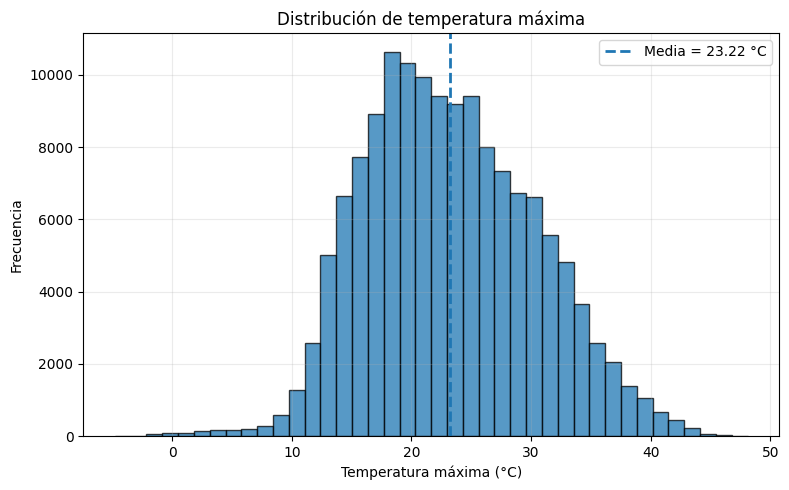

In [9]:
# Histograma de temperatura máxima
max_temp = df["MaxTemp"].dropna()

plt.figure(figsize=(8, 5))
plt.hist(max_temp, bins=40, edgecolor="black", alpha=0.75)
plt.axvline(max_temp.mean(), linestyle="--", linewidth=2, label=f"Media = {max_temp.mean():.2f} °C")
plt.title("Distribución de temperatura máxima")
plt.xlabel("Temperatura máxima (°C)")
plt.ylabel("Frecuencia")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "distribucion_temperatura_maxima.png", dpi=300, bbox_inches="tight")
plt.show()


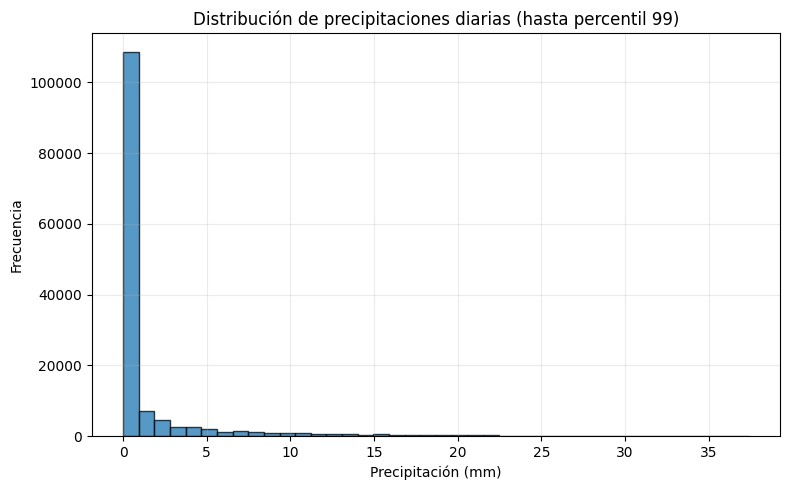

In [10]:
# Histograma de precipitaciones recortado al percentil 99 para mejorar legibilidad
rainfall = df["Rainfall"].dropna()
limite_p99 = rainfall.quantile(0.99)

plt.figure(figsize=(8, 5))
plt.hist(rainfall[rainfall <= limite_p99], bins=40, edgecolor="black", alpha=0.75)
plt.title("Distribución de precipitaciones diarias (hasta percentil 99)")
plt.xlabel("Precipitación (mm)")
plt.ylabel("Frecuencia")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "distribucion_precipitaciones.png", dpi=300, bbox_inches="tight")
plt.show()


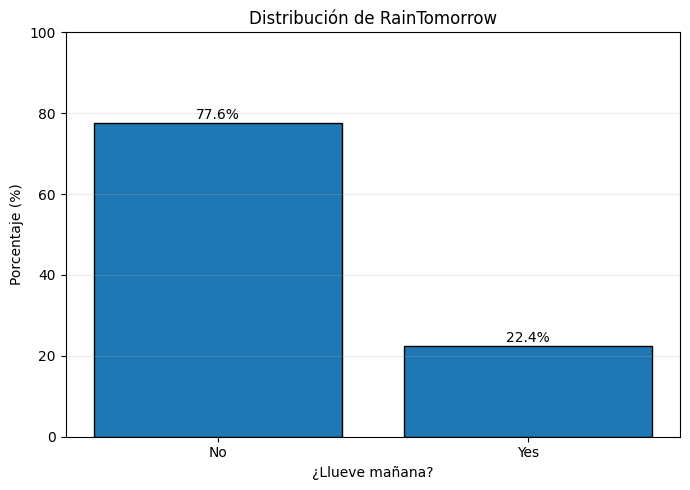

In [11]:
# Distribución de la variable objetivo
rain_tomorrow = df["RainTomorrow"].dropna().value_counts().sort_index()
porcentaje_rain = rain_tomorrow / rain_tomorrow.sum() * 100

plt.figure(figsize=(7, 5))
plt.bar(porcentaje_rain.index, porcentaje_rain.values, edgecolor="black")
plt.title("Distribución de RainTomorrow")
plt.xlabel("¿Llueve mañana?")
plt.ylabel("Porcentaje (%)")
for i, valor in enumerate(porcentaje_rain.values):
    plt.text(i, valor + 1, f"{valor:.1f}%", ha="center")
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "distribucion_rain_tomorrow.png", dpi=300, bbox_inches="tight")
plt.show()


/var/folders/8y/ylcpfmpd5csgjx_p31r99jmw0000gn/T/ipykernel_89002/955703418.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(grupos, labels=["No", "Yes"], showmeans=True)


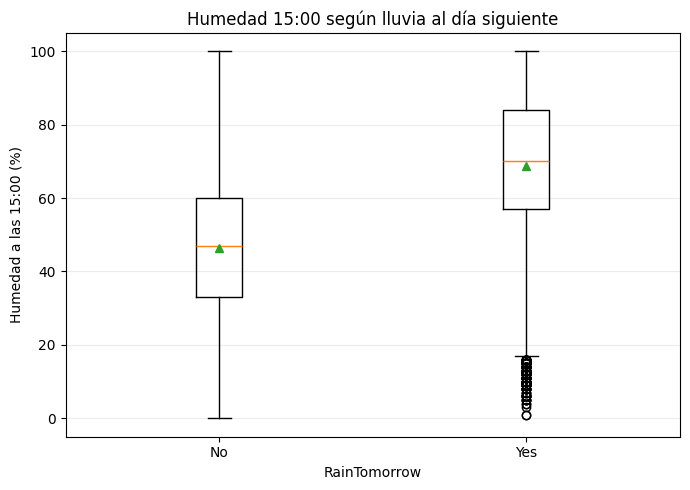

In [12]:
# Boxplot de humedad a las 15:00 según RainTomorrow
datos_box = df[["Humidity3pm", "RainTomorrow"]].dropna()
grupos = [
    datos_box.loc[datos_box["RainTomorrow"] == "No", "Humidity3pm"],
    datos_box.loc[datos_box["RainTomorrow"] == "Yes", "Humidity3pm"]
]

plt.figure(figsize=(7, 5))
plt.boxplot(grupos, labels=["No", "Yes"], showmeans=True)
plt.title("Humedad 15:00 según lluvia al día siguiente")
plt.xlabel("RainTomorrow")
plt.ylabel("Humedad a las 15:00 (%)")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "humedad_segun_lluvia.png", dpi=300, bbox_inches="tight")
plt.show()


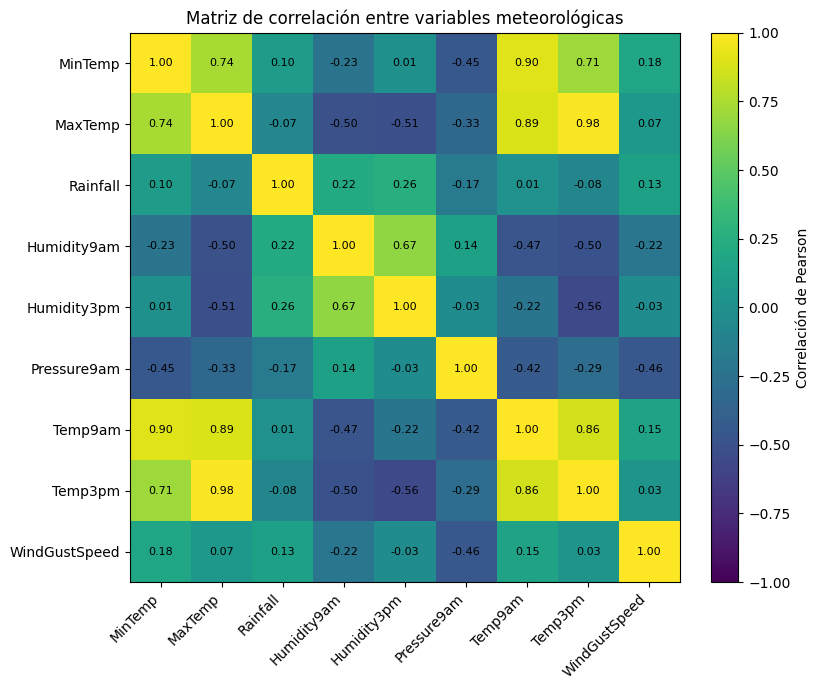

In [13]:
# Matriz de correlación
vars_corr = ["MinTemp", "MaxTemp", "Rainfall", "Humidity9am", "Humidity3pm", "Pressure9am", "Temp9am", "Temp3pm", "WindGustSpeed"]
corr = df[vars_corr].corr()

plt.figure(figsize=(9, 7))
im = plt.imshow(corr, vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04, label="Correlación de Pearson")
plt.xticks(range(len(vars_corr)), vars_corr, rotation=45, ha="right")
plt.yticks(range(len(vars_corr)), vars_corr)
plt.title("Matriz de correlación entre variables meteorológicas")

for i in range(len(vars_corr)):
    for j in range(len(vars_corr)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "matriz_correlacion.png", dpi=300, bbox_inches="tight")
plt.show()


## 9. Estimación puntual e intervalos de confianza (ID1.3)

Se estiman dos parámetros poblacionales relevantes:

1. La media poblacional de la temperatura máxima (`MaxTemp`).
2. La proporción poblacional de días con lluvia al día siguiente (`RainTomorrow = Yes`).


In [14]:
def intervalo_confianza_media(serie, confianza=0.95):
    """Calcula IC para la media con t de Student, asumiendo sigma poblacional desconocida."""
    datos = serie.dropna()
    n = len(datos)
    media = datos.mean()
    desviacion = datos.std(ddof=1)
    error_estandar = desviacion / np.sqrt(n)
    alpha = 1 - confianza
    t_critico = stats.t.ppf(1 - alpha / 2, df=n - 1)
    margen = t_critico * error_estandar
    return {
        "n": n,
        "estimacion": media,
        "limite_inferior": media - margen,
        "limite_superior": media + margen,
        "error_estandar": error_estandar
    }

def intervalo_confianza_proporcion(serie, valor_exito="Yes", confianza=0.95):
    """Calcula IC para una proporción usando aproximación normal."""
    datos = serie.dropna()
    n = len(datos)
    p_hat = (datos == valor_exito).mean()
    alpha = 1 - confianza
    z_critico = stats.norm.ppf(1 - alpha / 2)
    error_estandar = np.sqrt(p_hat * (1 - p_hat) / n)
    margen = z_critico * error_estandar
    return {
        "n": n,
        "estimacion": p_hat,
        "limite_inferior": p_hat - margen,
        "limite_superior": p_hat + margen,
        "error_estandar": error_estandar
    }

ic_maxtemp = intervalo_confianza_media(df["MaxTemp"])
ic_lluvia = intervalo_confianza_proporcion(df["RainTomorrow"])

resumen_ic = pd.DataFrame([
    {"Parametro": "Media MaxTemp (°C)", **ic_maxtemp},
    {"Parametro": "Proporción RainTomorrow = Yes", **ic_lluvia}
])

resumen_ic.round(4)


,Parametro,n,estimacion,limite_inferior,limite_superior,error_estandar
0,Media MaxTemp (°C),144199,23.22,23.18,23.26,0.02
1,Proporción RainTomorrow = Yes,142193,0.22,0.22,0.23,0.00


**Interpretación esperada:** con un 95% de confianza, la temperatura máxima media poblacional se encuentra dentro del intervalo estimado. Además, la proporción de días con lluvia al día siguiente se estima con alta precisión por el gran tamaño muestral.


## 10. Pruebas de hipótesis (ID1.4)

Se aplican dos pruebas básicas:

- **Prueba t de una muestra:** contrasta si la media de `MaxTemp` difiere de 22 °C.
- **Prueba t de Welch:** compara la humedad a las 15:00 entre días con y sin lluvia al día siguiente.


In [15]:
# Prueba 1: t de una muestra para MaxTemp
# H0: mu_MaxTemp = 22
# H1: mu_MaxTemp != 22
alpha = 0.05
maxtemp = df["MaxTemp"].dropna()
resultado_t_1muestra = stats.ttest_1samp(maxtemp, popmean=22)

print("Prueba t de una muestra: MaxTemp vs 22 °C")
print(f"Media muestral: {maxtemp.mean():.2f} °C")
print(f"Estadístico t: {resultado_t_1muestra.statistic:.2f}")
print(f"p-valor: {resultado_t_1muestra.pvalue:.6f}")
print("Decisión:", "Rechazar H0" if resultado_t_1muestra.pvalue < alpha else "No rechazar H0")


Prueba t de una muestra: MaxTemp vs 22 °C
Media muestral: 23.22 °C
Estadístico t: 65.15
p-valor: 0.000000
Decisión: Rechazar H0


In [16]:
# Prueba 2: t de Welch para Humidity3pm según RainTomorrow
# H0: mu_Humidity3pm_Yes = mu_Humidity3pm_No
# H1: mu_Humidity3pm_Yes != mu_Humidity3pm_No
humedad = df[["Humidity3pm", "RainTomorrow"]].dropna()
hum_yes = humedad.loc[humedad["RainTomorrow"] == "Yes", "Humidity3pm"]
hum_no = humedad.loc[humedad["RainTomorrow"] == "No", "Humidity3pm"]

resultado_welch = stats.ttest_ind(hum_yes, hum_no, equal_var=False)

print("Prueba t de Welch: Humidity3pm según RainTomorrow")
print(f"Media Humidity3pm cuando RainTomorrow = Yes: {hum_yes.mean():.2f}%")
print(f"Media Humidity3pm cuando RainTomorrow = No: {hum_no.mean():.2f}%")
print(f"Diferencia de medias: {hum_yes.mean() - hum_no.mean():.2f} puntos porcentuales")
print(f"Estadístico t: {resultado_welch.statistic:.2f}")
print(f"p-valor: {resultado_welch.pvalue:.6f}")
print("Decisión:", "Rechazar H0" if resultado_welch.pvalue < alpha else "No rechazar H0")


Prueba t de Welch: Humidity3pm según RainTomorrow
Media Humidity3pm cuando RainTomorrow = Yes: 68.80%
Media Humidity3pm cuando RainTomorrow = No: 46.51%
Diferencia de medias: 22.29 puntos porcentuales
Estadístico t: 182.61
p-valor: 0.000000
Decisión: Rechazar H0


## 11. Interpretación preliminar de resultados

A partir del análisis descriptivo e inferencial se observa que:

- `RainTomorrow` presenta desbalance: la mayoría de los registros corresponden a días sin lluvia al día siguiente.
- `Rainfall` tiene una distribución altamente asimétrica, porque muchos días registran 0 mm de precipitación y pocos eventos concentran lluvias intensas.
- La temperatura máxima promedio es cercana a 23,22 °C y su intervalo de confianza es estrecho debido al tamaño muestral.
- La proporción estimada de días con lluvia al día siguiente es cercana al 22,4%.
- La humedad a las 15:00 horas es considerablemente mayor en los días asociados a lluvia al día siguiente, por lo que aparece como una variable relevante para decisiones predictivas posteriores.

Estos resultados permiten construir una base estadística inicial para futuras fases del proyecto, especialmente si luego se desarrolla un modelo de clasificación para predecir `RainTomorrow`.


## 12. Documentación y trazabilidad

El análisis fue implementado en Python usando `pandas`, `numpy`, `matplotlib` y `scipy`. El notebook mantiene una estructura secuencial y reproducible:

1. Carga de datos.
2. Exploración inicial.
3. Clasificación de variables.
4. Estadística descriptiva.
5. Visualización.
6. Estimación por intervalos.
7. Pruebas de hipótesis.
8. Interpretación.

Para ejecutar el notebook en el repositorio, el archivo `weatherAUS.csv` debe ubicarse en `data/raw/weatherAUS.csv`. El conjunto transformado se guarda en `data/processed/weatherAUS.csv` y las visualizaciones en `results/figures/`.


## 13. Referencias

- Kaggle. (2017). *Rain in Australia / WeatherAUS Dataset*.
- McKinney, W. (2022). *Python for Data Analysis* (3rd ed.). O’Reilly Media.
- Virtanen, P. et al. (2020). SciPy 1.0: Fundamental Algorithms for Scientific Computing in Python. *Nature Methods*, 17, 261–272.
- pandas development team. (2024). *pandas documentation*.
- Hunter, J. D. (2007). Matplotlib: A 2D Graphics Environment. *Computing in Science & Engineering*, 9(3), 90–95.
